# Dataset V3 Heat Vulnerability Index

This notebook creates a Heat Vulnerability Index (HVI) for Chhatrapati Sambhajinagar using heat hazard and population exposure.

Heat hazard is represented by model-predicted baseline Land Surface Temperature. Population is used as an exposure proxy.

The HVI identifies zones where high heat and high population overlap. It complements hotspot detection because the hottest zone is not always the zone with the highest human risk.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Scenario output includes baseline predicted LST, population, coordinates, and Zone_ID
df_vulnerability_v3 = pd.read_csv(
    "../data/processed/scenario_predictions_v3.csv"
)

print("Dataset loaded successfully")
print("Shape:", df_vulnerability_v3.shape)

display(df_vulnerability_v3.head())

Dataset loaded successfully
Shape: (9893, 28)


,NDVI,NDBI,Elevation,Population,LandCover_Bare_sparse_vegetation,LandCover_Built-up land,LandCover_Cropland,LandCover_Grassland,LandCover_Permanent_water_bodies,LandCover_Shrubland,...,Lat_Block,Lon_Block,Zone_ID,Baseline_Predicted_LST,Greening_Predicted_LST,Greening_Cooling_C,Cool_Surface_Predicted_LST,Cool_Surface_Cooling_C,Best_Cooling_C,Recommended_Intervention
0,0.162286,0.127207,919,1.562392,0,0,1,0,0,0,...,12,14,12_14,44.202328,44.448135,-0.245808,44.449990,-0.247662,-0.245808,Urban greening
1,0.570751,-0.272423,488,1.361367,0,0,1,0,0,0,...,0,3,0_3,39.296585,39.301758,-0.005173,39.708134,-0.411549,-0.005173,Urban greening
2,0.099371,0.055877,505,15.386780,0,0,0,1,0,0,...,3,4,3_4,43.298996,43.949340,-0.650345,43.719433,-0.420437,-0.420437,Cool/permeable surfaces
3,0.196037,0.121404,757,2.643492,0,0,1,0,0,0,...,11,20,11_20,45.497520,45.407787,0.089733,45.506027,-0.008507,0.089733,Urban greening
4,0.165262,0.133151,586,31.397209,0,0,0,1,0,0,...,7,17,7_17,47.015200,46.217350,0.797852,46.364570,0.650631,0.797852,Urban greening


In [2]:
def min_max_normalize(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            np.zeros(len(series)),
            index=series.index
        )

    return (series - minimum) / (maximum - minimum)

In [3]:
# Heat hazard: baseline model-predicted LST
df_vulnerability_v3["Heat_Hazard_Score"] = min_max_normalize(
    df_vulnerability_v3["Baseline_Predicted_LST"]
)

# Exposure proxy: population
df_vulnerability_v3["Population_Exposure_Score"] = min_max_normalize(
    df_vulnerability_v3["Population"]
)

# Equal-weight Heat Vulnerability Index
df_vulnerability_v3["Heat_Vulnerability_Index"] = (
    0.5 * df_vulnerability_v3["Heat_Hazard_Score"]
    + 0.5 * df_vulnerability_v3["Population_Exposure_Score"]
)

print(
    df_vulnerability_v3[
        [
            "Baseline_Predicted_LST",
            "Population",
            "Heat_Hazard_Score",
            "Population_Exposure_Score",
            "Heat_Vulnerability_Index"
        ]
    ].describe().round(3)
)

       Baseline_Predicted_LST  Population  Heat_Hazard_Score  \
count                9893.000    9893.000           9893.000   
mean                   43.463      12.378              0.709   
std                     2.656      29.300              0.120   
min                    27.737       0.668              0.000   
25%                    41.638       2.063              0.626   
50%                    43.706       3.156              0.720   
75%                    45.634       7.111              0.807   
max                    49.928     230.775              1.000   

       Population_Exposure_Score  Heat_Vulnerability_Index  
count                   9893.000                  9893.000  
mean                       0.051                     0.380  
std                        0.127                     0.082  
min                        0.000                     0.002  
25%                        0.006                     0.328  
50%                        0.011                     0.38

In [4]:
hvi_q1 = df_vulnerability_v3["Heat_Vulnerability_Index"].quantile(0.25)
hvi_q2 = df_vulnerability_v3["Heat_Vulnerability_Index"].quantile(0.50)
hvi_q3 = df_vulnerability_v3["Heat_Vulnerability_Index"].quantile(0.75)

vulnerability_bins = [-np.inf, hvi_q1, hvi_q2, hvi_q3, np.inf]
vulnerability_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

df_vulnerability_v3["Vulnerability_Category"] = pd.cut(
    df_vulnerability_v3["Heat_Vulnerability_Index"],
    bins=vulnerability_bins,
    labels=vulnerability_labels,
    include_lowest=True
)

print("Vulnerability category counts:")
print(
    df_vulnerability_v3["Vulnerability_Category"]
    .value_counts()
    .reindex(vulnerability_labels)
)

Vulnerability category counts:
Vulnerability_Category
Low          2474
Moderate     2473
High         2473
Very High    2473
Name: count, dtype: int64


In [5]:
zone_vulnerability_v3 = (
    df_vulnerability_v3.groupby("Zone_ID")
    .agg(
        Mean_Baseline_LST=(
            "Baseline_Predicted_LST",
            "mean"
        ),
        Mean_Population=(
            "Population",
            "mean"
        ),
        Mean_Heat_Hazard_Score=(
            "Heat_Hazard_Score",
            "mean"
        ),
        Mean_Population_Exposure_Score=(
            "Population_Exposure_Score",
            "mean"
        ),
        Mean_Heat_Vulnerability_Index=(
            "Heat_Vulnerability_Index",
            "mean"
        ),
        Zone_Latitude=("Latitude", "mean"),
        Zone_Longitude=("Longitude", "mean"),
        Point_Count=("LST", "count")
    )
    .reset_index()
)

zone_vulnerability_v3 = zone_vulnerability_v3.sort_values(
    by="Mean_Heat_Vulnerability_Index",
    ascending=False
).reset_index(drop=True)

zone_vulnerability_v3.insert(
    0,
    "Vulnerability_Rank",
    range(1, len(zone_vulnerability_v3) + 1)
)

print("Top 10 most vulnerable zones:")
display(zone_vulnerability_v3.head(10))

Top 10 most vulnerable zones:


,Vulnerability_Rank,Zone_ID,Mean_Baseline_LST,Mean_Population,Mean_Heat_Hazard_Score,Mean_Population_Exposure_Score,Mean_Heat_Vulnerability_Index,Zone_Latitude,Zone_Longitude,Point_Count
0,1,7_9,41.775953,176.593178,0.632645,0.764538,0.698591,19.873852,75.332506,33
1,2,7_11,41.738128,166.682542,0.630940,0.721468,0.676204,19.873805,75.372631,30
2,3,7_10,41.376177,168.289624,0.614629,0.728452,0.671541,19.873351,75.352669,34
3,4,8_10,41.804171,158.789687,0.633916,0.687167,0.660542,19.893668,75.351290,37
4,5,6_10,42.258778,132.779434,0.654403,0.574131,0.614267,19.853567,75.350470,40
5,6,9_10,42.105616,127.969677,0.647501,0.553229,0.600365,19.912571,75.354301,30
6,7,8_9,41.618842,129.075473,0.625565,0.558035,0.591800,19.894061,75.329542,40
7,8,8_8,43.284214,105.591844,0.700613,0.455979,0.578296,19.894664,75.312489,23
8,9,8_11,43.220870,104.735721,0.697758,0.452259,0.575008,19.894265,75.373587,30
9,10,6_9,43.035631,100.174659,0.689411,0.432437,0.560924,19.852109,75.331116,32


In [6]:
zone_vulnerability_v3["Vulnerability_Priority"] = "Standard"

top_zone_count = min(10, len(zone_vulnerability_v3))

zone_vulnerability_v3.loc[
    zone_vulnerability_v3.index < top_zone_count,
    "Vulnerability_Priority"
] = "High Priority"

print(
    zone_vulnerability_v3["Vulnerability_Priority"]
    .value_counts()
)

Vulnerability_Priority
Standard         324
High Priority     10
Name: count, dtype: int64


In [7]:
hotspot_zones_v3 = pd.read_csv(
    "../outputs/reports/hotspot_zone_priority_v3.csv"
)

top_hottest_zone_ids = set(
    hotspot_zones_v3
    .sort_values("Mean_LST", ascending=False)
    .head(10)["Zone_ID"]
)

top_vulnerable_zone_ids = set(
    zone_vulnerability_v3
    .head(10)["Zone_ID"]
)

overlap_zone_ids = top_hottest_zone_ids.intersection(
    top_vulnerable_zone_ids
)

print("Top hottest zones:", len(top_hottest_zone_ids))
print("Top vulnerable zones:", len(top_vulnerable_zone_ids))
print("Zones appearing in both lists:", len(overlap_zone_ids))
print("Overlapping Zone IDs:", sorted(overlap_zone_ids))

Top hottest zones: 10
Top vulnerable zones: 10
Zones appearing in both lists: 0
Overlapping Zone IDs: []


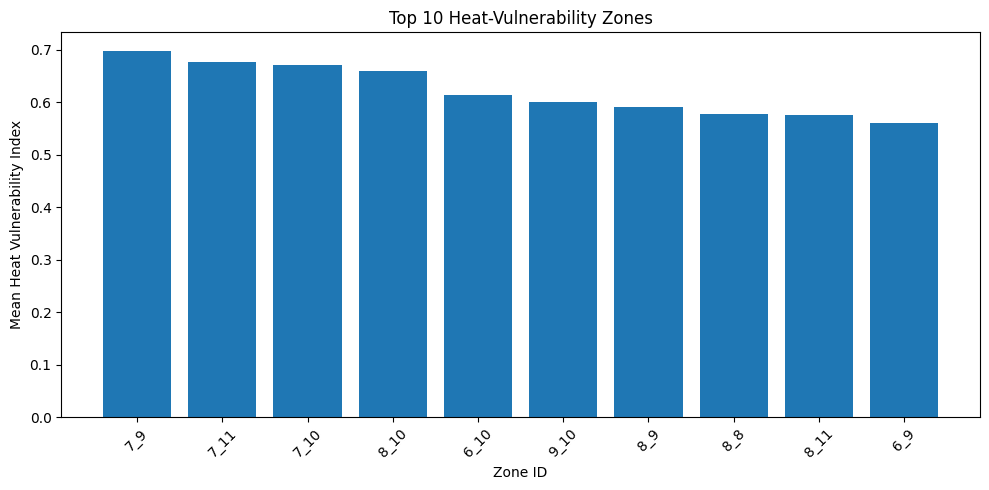

In [8]:
top_vulnerable_plot = zone_vulnerability_v3.head(10).copy()

plt.figure(figsize=(10, 5))
plt.bar(
    top_vulnerable_plot["Zone_ID"],
    top_vulnerable_plot["Mean_Heat_Vulnerability_Index"]
)

plt.title("Top 10 Heat-Vulnerability Zones")
plt.xlabel("Zone ID")
plt.ylabel("Mean Heat Vulnerability Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

df_vulnerability_v3.to_csv(
    "../data/processed/vulnerability_predictions_v3.csv",
    index=False
)

zone_vulnerability_v3.to_csv(
    "../outputs/reports/zone_vulnerability_v3.csv",
    index=False
)

print("Saved:")
print("data/processed/vulnerability_predictions_v3.csv")
print("outputs/reports/zone_vulnerability_v3.csv")

Saved:
data/processed/vulnerability_predictions_v3.csv
outputs/reports/zone_vulnerability_v3.csv


## Dataset V3 Heat Vulnerability Conclusion

The Heat Vulnerability Index combines model-predicted heat hazard with population exposure using equal weights.

Zones were ranked by mean Heat Vulnerability Index, and the top 10 zones were marked as High Priority.

This analysis complements hotspot detection. A zone with moderate heat but high population exposure may have greater human risk than a hotter zone with low population exposure.

The index is a planning-support indicator based on available data. Future versions can add sensitivity indicators such as age, income, housing quality, and access to cooling infrastructure.